In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid", palette="Set2",font_scale=1.1)

In [2]:
df = pd.read_csv("../data/processed/anime_cleaned.csv")

In [3]:
df.head()

,mal_id,title,title_english,title_japanese,type,episodes,status,score,rank,popularity,members,favorites,synopsis,genres,themes,demographics,studios,year,url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,26.0,Finished Airing,8.75,46.0,42,1975882,86621,"Crime is timeless. By the year 2071, humanity has expanded across the galaxy, filling the surface of other planets with settlements like those on ...","Action, Award Winning, Sci-Fi","Adult Cast, Space",Unknown,Sunrise,1998.0,https://myanimelist.net/anime/1/Cowboy_Bebop
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,1.0,Finished Airing,8.38,215.0,642,398122,1711,"Another day, another bounty—such is the life of the often unlucky crew of the Bebop. However, this routine is interrupted when Faye, who is chasin...","Action, Sci-Fi","Adult Cast, Space",Unknown,Bones,NaN,https://myanimelist.net/anime/5/Cowboy_Bebop__Tengoku_no_Tobira
2,6,Trigun,Trigun,トライガン,TV,26.0,Finished Airing,8.22,378.0,260,803358,16863,"Vash the Stampede is the man with a $$60,000,000,000 bounty on his head. The reason: he's a merciless villain who lays waste to all those that opp...","Action, Adventure, Sci-Fi",Adult Cast,Shounen,Madhouse,1998.0,https://myanimelist.net/anime/6/Trigun
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26.0,Finished Airing,7.23,3260.0,1950,123424,674,"Though hidden away from the general public, Witches—those with supernatural powers—have always existed in human societies. Neither numerous nor in...","Action, Drama, Mystery, Supernatural",Detective,Unknown,Sunrise,2002.0,https://myanimelist.net/anime/7/Witch_Hunter_Robin
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,52.0,Finished Airing,6.92,4819.0,5655,16308,16,"It is the dark century and the people are suffering under the rule of the devil, Vandel, who is able to manipulate monsters. The Vandel Busters ar...","Action, Adventure, Fantasy",Unknown,Shounen,Toei Animation,2004.0,https://myanimelist.net/anime/8/Bouken_Ou_Beet


In [4]:
df.shape

(28491, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28491 entries, 0 to 28490
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mal_id          28491 non-null  int64  
 1   title           28491 non-null  str    
 2   title_english   12232 non-null  str    
 3   title_japanese  28374 non-null  str    
 4   type            28491 non-null  str    
 5   episodes        28491 non-null  float64
 6   status          28491 non-null  str    
 7   score           18540 non-null  float64
 8   rank            21725 non-null  float64
 9   popularity      28491 non-null  int64  
 10  members         28491 non-null  int64  
 11  favorites       28491 non-null  int64  
 12  synopsis        23443 non-null  str    
 13  genres          28491 non-null  str    
 14  themes          28491 non-null  str    
 15  demographics    28491 non-null  str    
 16  studios         28491 non-null  str    
 17  year            6154 non-null   float64
 1

In [6]:
df.describe(include="all")

,mal_id,title,title_english,title_japanese,type,episodes,status,score,rank,popularity,members,favorites,synopsis,genres,themes,demographics,studios,year,url
count,28491.000000,28491,12232,28374,28491,28491.000000,28491,18540.000000,21725.000000,28491.000000,2.849100e+04,28491.000000,23443,28491,28491,28491,28491,6154.000000,28491
unique,NaN,28489,12034,27318,9,NaN,3,NaN,NaN,NaN,NaN,NaN,23160,930,1027,9,1872,NaN,28491
top,NaN,Shen Lan Qi Yu Wushuang Zhu: Tianmo Pian,Promise,おしりたんてい,TV,NaN,Finished Airing,NaN,NaN,NaN,NaN,NaN,No synopsis has been added for this series yet.\n\nClick here to update this information.,Unknown,Unknown,Unknown,Unknown,NaN,https://myanimelist.net/anime/1/Cowboy_Bebop
freq,NaN,2,5,9,8355,NaN,27611,NaN,NaN,NaN,NaN,NaN,24,5889,11722,17822,11552,NaN,1
mean,33484.859886,NaN,NaN,NaN,NaN,13.886139,NaN,6.396173,10864.481749,14246.202555,3.864502e+04,432.577902,NaN,NaN,NaN,NaN,NaN,2009.779818,NaN
std,19419.703309,NaN,NaN,NaN,NaN,46.863630,NaN,0.889634,6273.094420,8225.095526,1.664306e+05,4507.470784,NaN,NaN,NaN,NaN,NaN,13.175352,NaN
min,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,1.890000,1.000000,1.000000,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,1961.000000,NaN
25%,14541.000000,NaN,NaN,NaN,NaN,1.000000,NaN,5.780000,5433.000000,7123.500000,2.350000e+02,0.000000,NaN,NaN,NaN,NaN,NaN,2004.000000,NaN
50%,37563.000000,NaN,NaN,NaN,NaN,2.000000,NaN,6.370000,10861.000000,14246.000000,1.081000e+03,1.000000,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
75%,49719.500000,NaN,NaN,NaN,NaN,13.000000,NaN,7.030000,16295.000000,21367.000000,9.161000e+03,17.000000,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN


# Dataset Snapshot

| Metric | Value |
|--------|------:|
| Total Anime | 28,491 |
| Total Features | 19 |
| Recommendation Type | Content-Based |
| Dataset Source | MyAnimeList |
| Missing Values | Handled During Cleaning |
| Duplicate Records Removed | 216 |

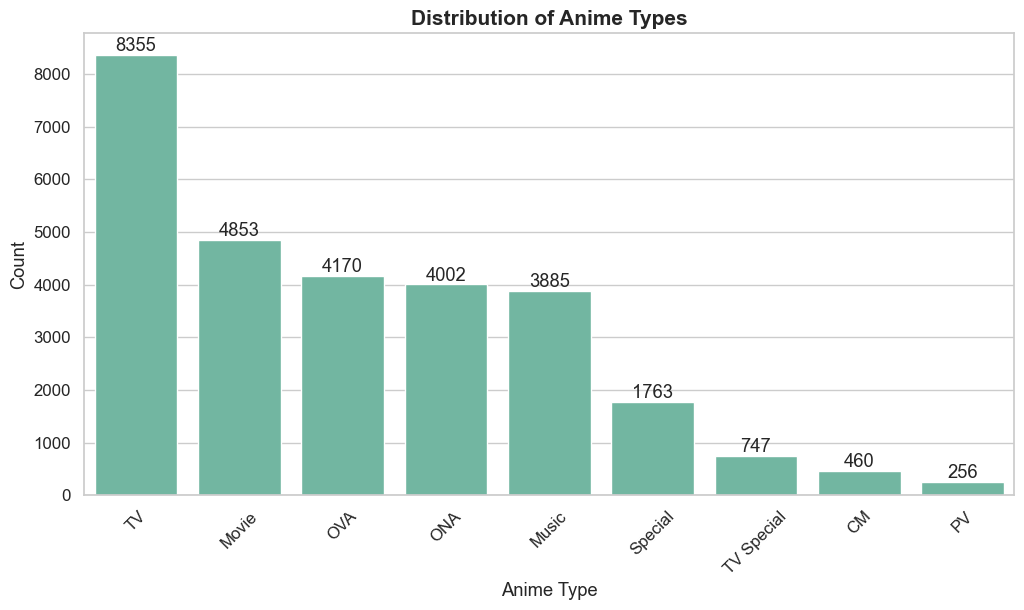

In [7]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Anime Types", fontsize=15, fontweight="bold")
plt.xlabel("Anime Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(
    "../images/anime_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
type_summary = (
    df["type"]
    .value_counts()
    .reset_index()
)

type_summary.columns = ["Anime Type", "Count"]

type_summary

,Anime Type,Count
0,TV,8355
1,Movie,4853
2,OVA,4170
3,ONA,4002
4,Music,3885
5,Special,1763
6,TV Special,747
7,CM,460
8,PV,256


### Interpretation

The dataset is dominated by TV anime, followed by Movies, OVAs, ONAs, and Music anime. Promotional videos (PV) and Commercials (CM) represent only a small portion of the dataset.

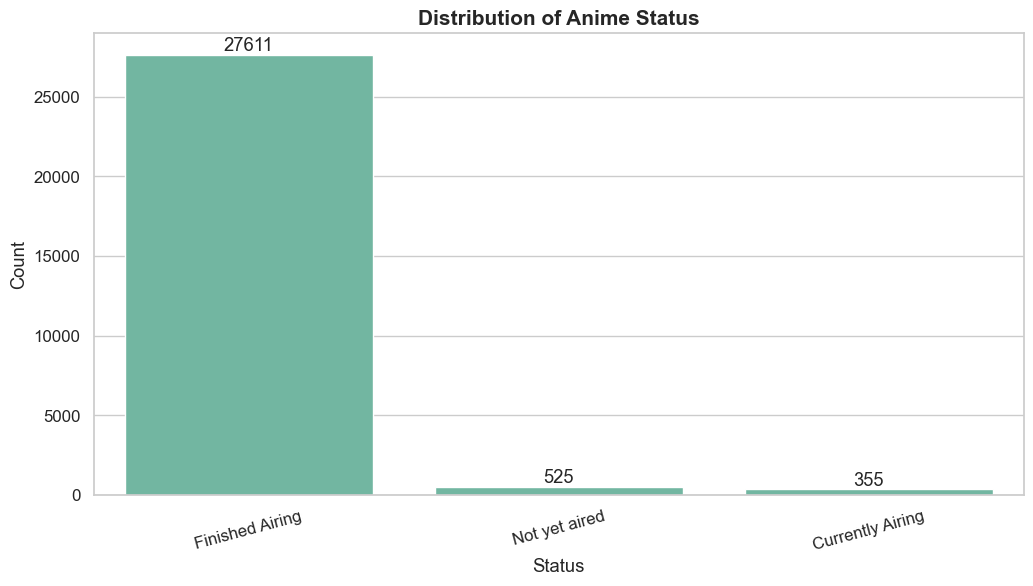

In [9]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="status",
    order=df["status"].value_counts().index
)

plt.title("Distribution of Anime Status", fontsize=15, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Count")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(
    "../images/anime_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
status_summary = (
    df["status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = ["Status", "Count"]

status_summary

,Status,Count
0,Finished Airing,27611
1,Not yet aired,525
2,Currently Airing,355


In [11]:
# Split multiple genres into individual genres
genre_counts = (
    df["genres"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)
genre_counts = genre_counts.drop("Unknown", errors="ignore")
genre_counts.head(15)

genres
Comedy           7688
Fantasy          5934
Action           5552
Adventure        4372
Sci-Fi           3427
Drama            3060
Romance          2168
Hentai           1575
Slice of Life    1554
Supernatural     1536
Avant Garde      1045
Mystery           984
Ecchi             818
Sports            807
Horror            578
Name: count, dtype: int64

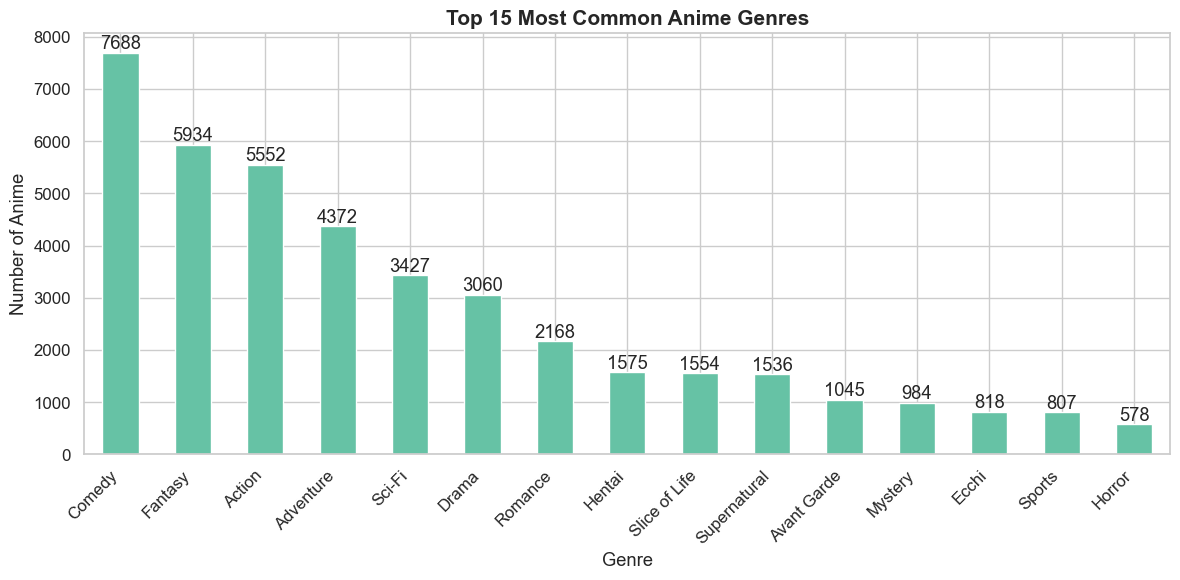

In [12]:
plt.figure(figsize=(12,6))

ax = genre_counts.head(15).plot(kind="bar")

plt.title("Top 15 Most Common Anime Genres", fontsize=15, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Number of Anime")

plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/top_15_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Comedy is the most common genre in the dataset, followed by Fantasy, Action, and Adventure. These genres dominate the anime catalog, while genres such as Sports and Ecchi appear less frequently among the top 15.

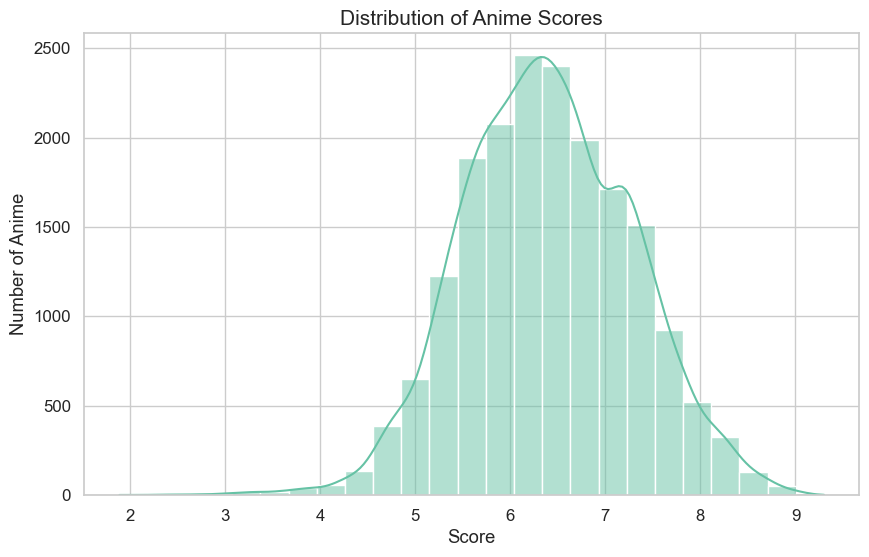

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="score",
    bins=25,
    kde=True
)

plt.title("Distribution of Anime Scores", fontsize=15)
plt.xlabel("Score")
plt.ylabel("Number of Anime")

plt.savefig(
    "../images/score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Most anime scores are concentrated between 5.5 and 7.5, with the highest density around 6 to 7. Very few anime have extremely low or extremely high ratings.

In [14]:
top_rated = (
    df[["title", "score"]]
    .dropna()
    .sort_values(by="score", ascending=False)
    .head(10)
)

top_rated

,title,score
23057,Sousou no Frieren,9.30
3960,Fullmetal Alchemist: Brotherhood,9.10
5664,Steins;Gate,9.07
14842,Shingeki no Kyojin Season 3 Part 2,9.05
9873,Gintama°,9.05
27403,One Piece Fan Letter,9.04
15498,Gintama: The Final,9.04
6453,Hunter x Hunter (2011),9.03
7237,Gintama': Enchousen,9.02
5986,Gintama',9.02


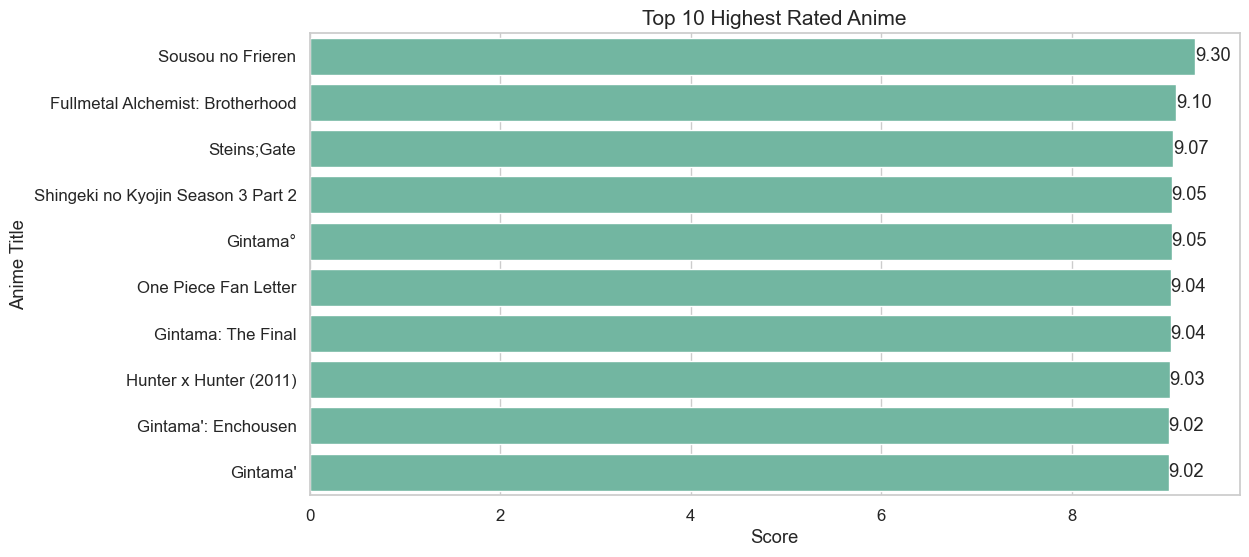

In [15]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_rated,
    x="score",
    y="title"
)

plt.title("Top 10 Highest Rated Anime", fontsize=15)
plt.xlabel("Score")
plt.ylabel("Anime Title")

# Add score labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.savefig(
    "../images/top_10_highest_rated_anime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The highest-rated anime in the dataset have scores above 9.0, indicating exceptional audience appreciation. Titles such as Sousou no Frieren, Fullmetal Alchemist: Brotherhood, and Steins;Gate consistently rank among the best-rated anime.

In [16]:
top_members = (
    df[["title", "members"]]
    .sort_values(by="members", ascending=False)
    .head(10)
)

top_members

,title,members
7425,Shingeki no Kyojin,4173914
1393,Death Note,4117505
3960,Fullmetal Alchemist: Brotherhood,3531778
10401,One Punch Man,3391932
14520,Kimetsu no Yaiba,3262840
6593,Sword Art Online,3203893
11127,Boku no Hero Academia,3177202
6453,Hunter x Hunter (2011),3033288
10,Naruto,2999142
8613,Tokyo Ghoul,2953180


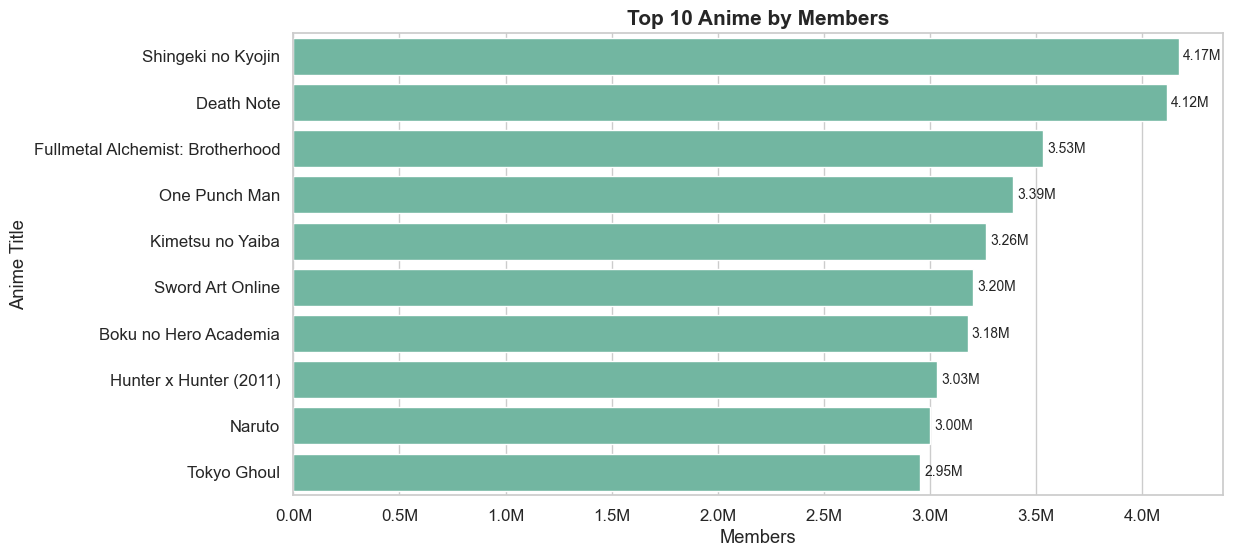

In [17]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_members,
    x="members",
    y="title"
)

plt.title("Top 10 Anime by Members", fontsize=15, fontweight="bold")
plt.xlabel("Members")
plt.ylabel("Anime Title")


ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)


for i, value in enumerate(top_members["members"]):
    ax.text(
        value + 20000,
        i,
        f"{value/1e6:.2f}M",
        va="center",
        fontsize=10
    )

plt.savefig(
    "../images/top_10_members.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Attack on Titan has the highest number of members in the dataset, followed closely by Death Note and Fullmetal Alchemist: Brotherhood. These anime have attracted the largest audiences on MyAnimeList.

In [18]:
top_favorites = (
    df[["title", "favorites"]]
    .sort_values(by="favorites", ascending=False)
    .head(10)
)

top_favorites

,title,favorites
11,One Piece,238872
3960,Fullmetal Alchemist: Brotherhood,234287
6453,Hunter x Hunter (2011),221321
5664,Steins;Gate,196526
7425,Shingeki no Kyojin,180962
1393,Death Note,180453
1574,Naruto: Shippuuden,116703
1431,Code Geass: Hangyaku no Lelouch,112975
20,Shinseiki Evangelion,112342
16201,Jujutsu Kaisen,93719


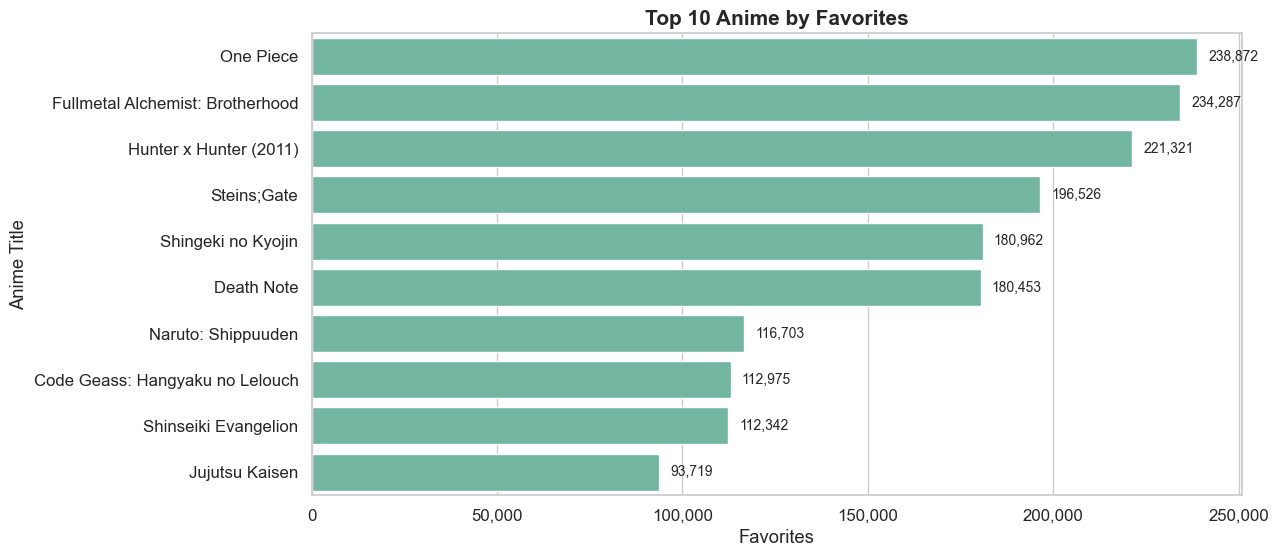

In [19]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_favorites,
    x="favorites",
    y="title"
)

plt.title("Top 10 Anime by Favorites", fontsize=15, fontweight="bold")
plt.xlabel("Favorites")
plt.ylabel("Anime Title")


ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}")
)


for i, value in enumerate(top_favorites["favorites"]):
    ax.text(
        value + 3000,
        i,
        f"{value:,}",
        va="center",
        fontsize=10
    )

plt.savefig(
    "../images/top_10_favorites.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

One Piece has the highest number of favorites, followed by Fullmetal Alchemist: Brotherhood and Hunter x Hunter (2011). Unlike the Members analysis, the Favorites metric highlights anime that users admire enough to mark as personal favorites.

In [20]:
top_popularity = (
    df[["title", "popularity"]]
    .sort_values(by="popularity")
    .head(10)
)

top_popularity

,title,popularity
7425,Shingeki no Kyojin,1
1393,Death Note,2
3960,Fullmetal Alchemist: Brotherhood,3
10401,One Punch Man,4
14520,Kimetsu no Yaiba,5
6593,Sword Art Online,6
11127,Boku no Hero Academia,7
6453,Hunter x Hunter (2011),8
10,Naruto,9
8613,Tokyo Ghoul,10


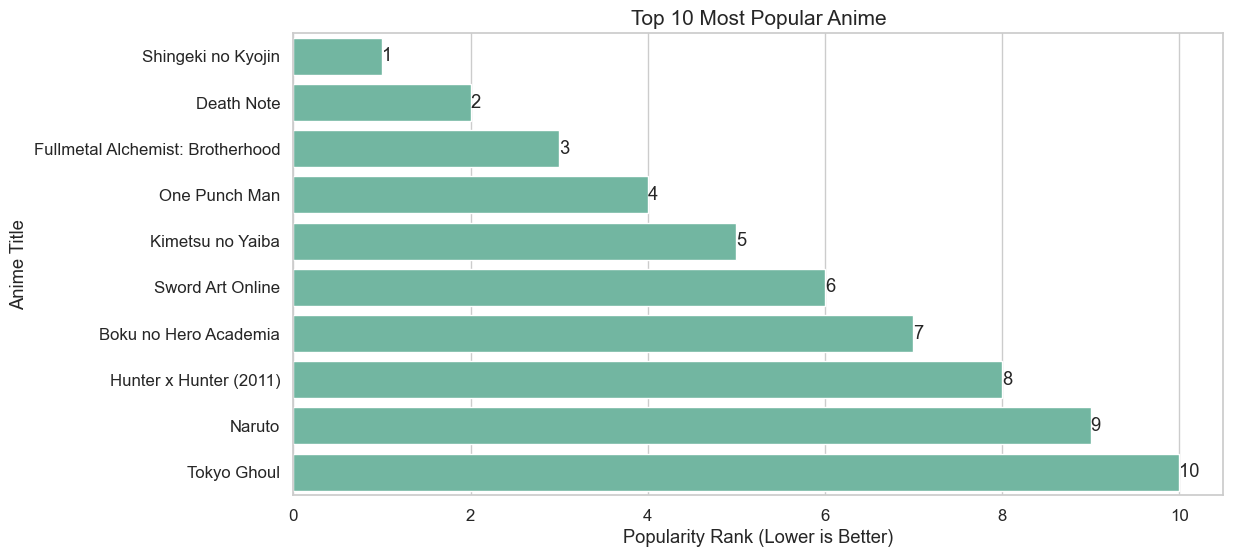

In [21]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_popularity,
    x="popularity",
    y="title"
)

plt.title("Top 10 Most Popular Anime", fontsize=15)
plt.xlabel("Popularity Rank (Lower is Better)")
plt.ylabel("Anime Title")

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(
    "../images/top_10_popular_anime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Attack on Titan ranks as the most popular anime on MyAnimeList, followed by Death Note and Fullmetal Alchemist: Brotherhood. These titles consistently maintain the highest visibility and audience reach within the anime community.

In [22]:
studio_counts = (
    df["studios"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

# Remove placeholder value
studio_counts = studio_counts.drop("Unknown", errors="ignore")

studio_counts.head(15)

studios
Toei Animation                    913
Sunrise                           579
J.C.Staff                         440
TMS Entertainment                 393
Madhouse                          380
Production I.G                    360
Shanghai Animation Film Studio    342
Studio Deen                       322
OLM                               303
Pierrot                           287
Shin-Ei Animation                 272
A-1 Pictures                      254
DLE                               227
Nippon Animation                  226
AIC                               199
Name: count, dtype: int64

In [23]:
theme_counts = (
    df["themes"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

theme_counts = theme_counts.drop("Unknown", errors="ignore")

theme_counts.head(15)

themes
Music              4988
School             2212
Historical         1699
Mecha              1306
Anthropomorphic    1191
Parody              800
Military            735
Super Power         713
Martial Arts        701
Adult Cast          700
Space               666
Mythology           643
Harem               480
Psychological       449
Isekai              438
Name: count, dtype: int64

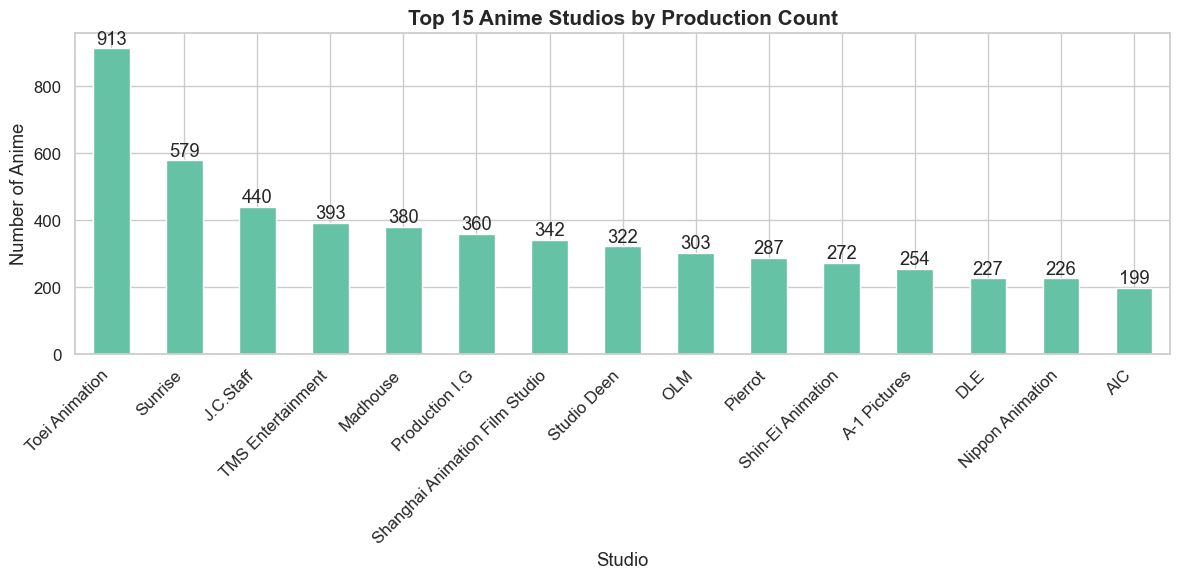

In [24]:
plt.figure(figsize=(12,6))

ax = studio_counts.head(15).plot(kind="bar")

plt.title("Top 15 Anime Studios by Production Count", fontsize=15,fontweight="bold")
plt.xlabel("Studio")
plt.ylabel("Number of Anime")

plt.xticks(rotation=45,ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    "../images/top_15_studios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




### Interpretation

Toei Animation has produced the highest number of anime in the dataset, followed by Sunrise, J.C.Staff, and Madhouse. These studios have consistently contributed a large volume of anime across different genres and years.

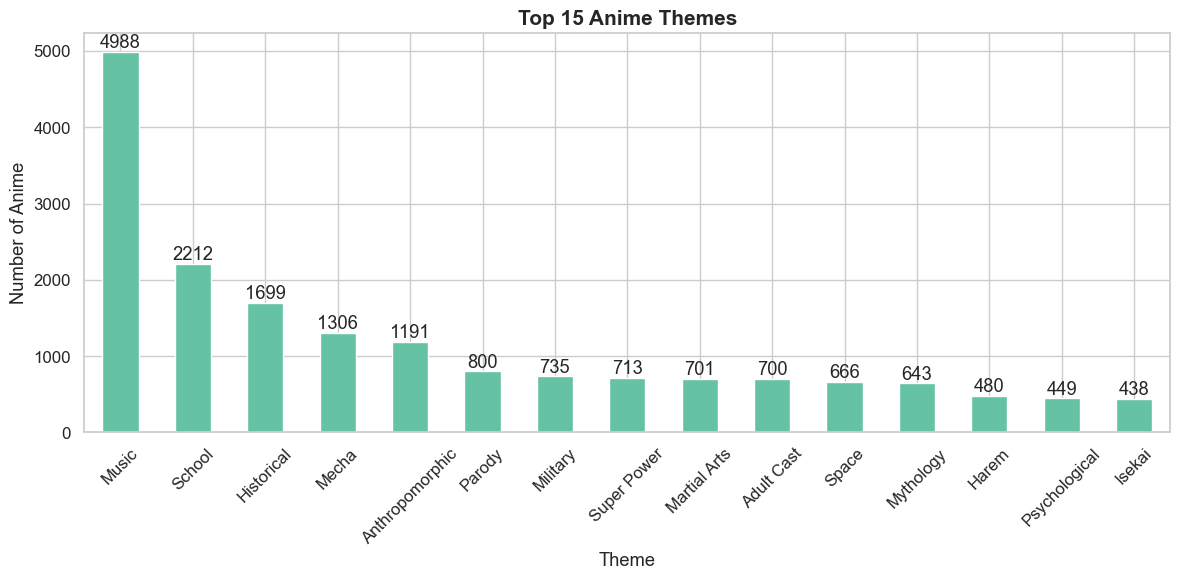

In [25]:
plt.figure(figsize=(12,6))

ax = theme_counts.head(15).plot(kind="bar")

plt.title("Top 15 Anime Themes", fontsize=15,fontweight="bold")
plt.xlabel("Theme")
plt.ylabel("Number of Anime")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(
    "../images/top_15_themes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Music, School, and Historical are the most frequently occurring themes in the dataset. These themes appear across a wide range of anime and contribute significantly to content diversity.

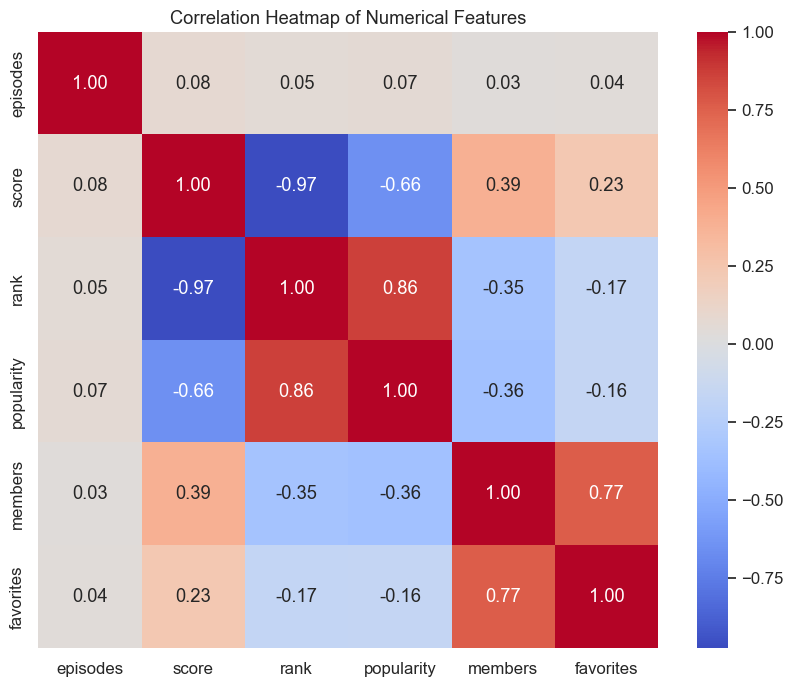

In [26]:
plt.figure(figsize=(10,8))

corr = df[
    ["episodes",
     "score",
     "rank",
     "popularity",
     "members",
     "favorites"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## EDA Conclusion

The exploratory analysis revealed that TV anime dominate the dataset and that the majority of anime have already completed airing. Comedy, Fantasy, and Action are the most common genres, while Toei Animation is the leading studio by production volume.

User engagement metrics show that Attack on Titan has the largest audience reach, whereas One Piece has the highest number of favorites, demonstrating the difference between popularity and user preference.

These insights provide a strong foundation for Feature Engineering, where genres, themes, studios, and synopsis will be transformed into recommendation features.